# CST 407 PYTHON FOR AI
### Midterm

### 1. Get familiar with the data set: Read the file in python, determine the number of classes, determine how many data points are available from each class etc.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import keras_tuner as kt

import warnings
warnings.filterwarnings('ignore')

E0000 00:00:1778910702.881871 16058592 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1778910702.883137 16058592 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1778910702.883141 16058592 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1778910702.883143 16058592 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1778910702.883145 16058592 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


In [2]:
df = pd.read_csv("cinnamoncut-org.csv")

df = df.dropna()

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1938, 12)

Column Names:
['Time', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'Prediction']

First 5 rows:


,Time,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,Prediction
0,0.9957,-202.8278,-300.9947,-32.7210,-28.7083,2.09000,-19.2894,-8.1354,-14.8272,-51.2078,-77.2282,8
1,2.7127,-198.6301,-294.6635,-31.2472,-28.2037,1.40000,-18.6851,-7.6441,-13.9881,-50.0268,-74.5923,8
2,4.3999,-199.7061,-295.2322,-31.1140,-28.4759,0.86738,-18.4943,-7.5095,-13.5574,-50.3209,-74.2716,8
3,6.0966,-203.4291,-300.8820,-31.7223,-29.1284,0.10589,-18.6515,-7.7036,-13.5517,-51.5892,-75.4215,8
4,7.8065,-208.1985,-308.7193,-32.8232,-29.9207,-0.43512,-18.9883,-8.0178,-13.5492,-53.1249,-77.4681,8


In [3]:
print("Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Data Types:
Time          float64
c1            float64
c2            float64
c3            float64
c4            float64
c5            float64
c6            float64
c7            float64
c8            float64
c9            float64
c10           float64
Prediction      int64
dtype: object

Basic Statistics:


,Time,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,Prediction
count,1938.000000,1938.000000,1938.000000,1938.000000,1938.000000,1938.000000,1938.000000,1938.000000,1938.000000,1938.000000,1938.000000,1938.000000
mean,5867.917380,-215.508351,-379.108464,-80.085343,-24.596293,-12.326182,-12.366576,-10.798092,-6.831771,-59.943608,-94.825013,18.508772
std,3003.630754,69.222243,81.411123,25.477288,17.716156,4.555073,6.571054,3.995604,3.710905,20.034301,37.816531,5.844675
min,0.995700,-354.169700,-550.028000,-144.769600,-52.931900,-23.584800,-23.808600,-21.888100,-14.958800,-103.117100,-172.472000,8.000000
25%,3142.238425,-270.830275,-442.707700,-97.252900,-40.658200,-15.210100,-19.823925,-11.932200,-10.674225,-75.016300,-126.783575,13.000000
50%,6176.837200,-183.680650,-358.339400,-70.131400,-19.462200,-11.492100,-10.540300,-9.891850,-6.036200,-50.451250,-73.111900,20.000000
75%,8542.619300,-155.665475,-307.989350,-60.118475,-10.892450,-8.561500,-8.072175,-7.988775,-3.970200,-44.550075,-62.505400,23.000000
max,9848.776500,-88.909000,-167.409700,-31.114000,9.630500,2.090000,-1.430500,1.053900,-0.277360,-23.798300,-41.905900,29.000000


In [4]:
label_col = df.columns[-1]
feature_cols = df.columns[:-1].tolist()

print(f"Label column  : '{label_col}'")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

Label column  : 'Prediction'
Feature columns (11): ['Time', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10']


Number of distinct cinnamon classes: 17

Data points per class:
Prediction
8      75
9      98
10     75
11    104
12     73
13     84
15     84
16    123
17     95
18     89
20    184
21     96
22    177
23    198
24    196
27     95
29     92
Name: count, dtype: int64


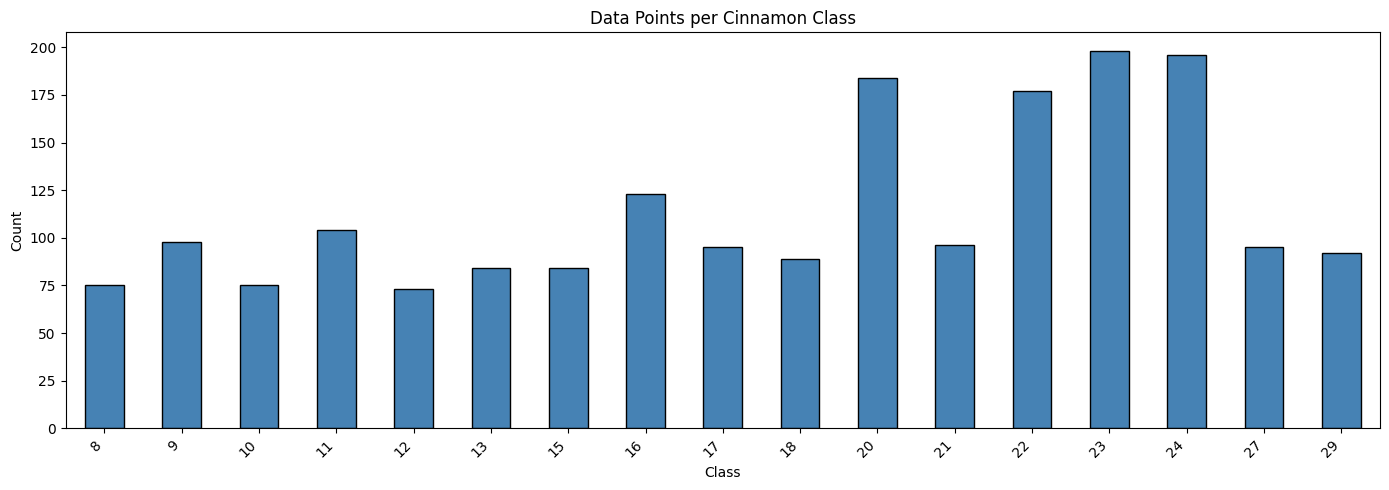


Total data points: 1938
Min samples in a class: 73 (12)
Max samples in a class: 198 (23)


In [5]:
labels = df[label_col]
num_classes = labels.nunique()
class_counts = labels.value_counts().sort_index()

print(f"Number of distinct cinnamon classes: {num_classes}")
print("\nData points per class:")
print(class_counts)

plt.figure(figsize=(14, 5))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Data Points per Cinnamon Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal data points: {len(df)}")
print(f"Min samples in a class: {class_counts.min()} ({class_counts.idxmin()})")
print(f"Max samples in a class: {class_counts.max()} ({class_counts.idxmax()})")

### 2. Now split the data into two parts: training.csv, test.csv. While splitting the data make sure that each class is represented in both files with enough data points. The optimum number of data points on training.csv and test.csv should be determined by you

In [6]:
label_col = df.columns[-1]
feature_cols = df.columns[:-1].tolist()

X = df[feature_cols].to_numpy()
y_raw = df[label_col].astype(str).to_numpy()

le = LabelEncoder()
y = le.fit_transform(y_raw)

num_classes = len(le.classes_)
print("Classes:", le.classes_)
print(f"Number of classes: {num_classes}")

Classes: ['10' '11' '12' '13' '15' '16' '17' '18' '20' '21' '22' '23' '24' '27'
 '29' '8' '9']
Number of classes: 17


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")
print(f"Feature dimensions: {X_train.shape[1]}")

Training set size : 1550 samples
Test set size     : 388 samples
Feature dimensions: 11


In [8]:
print("Training class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.inverse_transform(unique), counts):
    print(f"  {cls}: {cnt}")

print("\nTest class distribution:")
unique_t, counts_t = np.unique(y_test, return_counts=True)
for cls, cnt in zip(le.inverse_transform(unique_t), counts_t):
    print(f"  {cls}: {cnt}")

Training class distribution:
  10: 60
  11: 83
  12: 59
  13: 67
  15: 67
  16: 98
  17: 76
  18: 71
  20: 147
  21: 77
  22: 142
  23: 158
  24: 157
  27: 76
  29: 74
  8: 60
  9: 78

Test class distribution:
  10: 15
  11: 21
  12: 14
  13: 17
  15: 17
  16: 25
  17: 19
  18: 18
  20: 37
  21: 19
  22: 35
  23: 40
  24: 39
  27: 19
  29: 18
  8: 15
  9: 20


In [9]:
train_df = pd.DataFrame(X_train, columns=feature_cols)
train_df[label_col] = le.inverse_transform(y_train)

test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df[label_col] = le.inverse_transform(y_test)

train_df.to_csv("training.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("training.csv saved:", train_df.shape)
print("test.csv     saved:", test_df.shape)

training.csv saved: (1550, 12)
test.csv     saved: (388, 12)


### 3. Mkae the necessary data and label modifications so that you can feed it to your NN structure.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training data after scaling:")
print(f"  mean : {X_train_scaled.mean():.4f}  (should be ~0)")
print(f"  std  : {X_train_scaled.std():.4f}   (should be ~1)")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")
print(f"y_train shape        : {y_train.shape}")
print(f"y_test  shape        : {y_test.shape}")

Training data after scaling:
  mean : -0.0000  (should be ~0)
  std  : 1.0000   (should be ~1)

X_train_scaled shape: (1550, 11)
X_test_scaled  shape: (388, 11)
y_train shape        : (1550,)
y_test  shape        : (388,)


### 4. Construct your first NN structure. Only use dense layers. Determine the number of layers, the activation functions for layers, loss criteria, optomizer and other parameters needed.

In [11]:
num_features = X_train_scaled.shape[1]

model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(num_features,)),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(32,  activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 17)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,433 (48.57 KB)

 Trainable params: 12,433 (48.57 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Run your first NN structure and plot the confusion matrix. Comment on first results.

In [12]:
history1 = model1.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3052 - loss: 2.3662 - val_accuracy: 0.6495 - val_loss: 1.8330
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7265 - loss: 1.3261 - val_accuracy: 0.8144 - val_loss: 0.8457
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8445 - loss: 0.6467 - val_accuracy: 0.8479 - val_loss: 0.4918
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9097 - loss: 0.4052 - val_accuracy: 0.8995 - val_loss: 0.3390
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9387 - loss: 0.2911 - val_accuracy: 0.9562 - val_loss: 0.2343
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9755 - loss: 0.1993 - val_accuracy: 0.9742 - val_loss: 0.1794
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9832 - loss: 0.1447 - val_accuracy: 0.9716 - val_loss: 0.1417
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9968 - loss: 0.1045 - val_accuracy: 0.9845 - val_loss:

Model 1 - Test Loss    : 0.0032
Model 1 - Test Accuracy: 99.74%


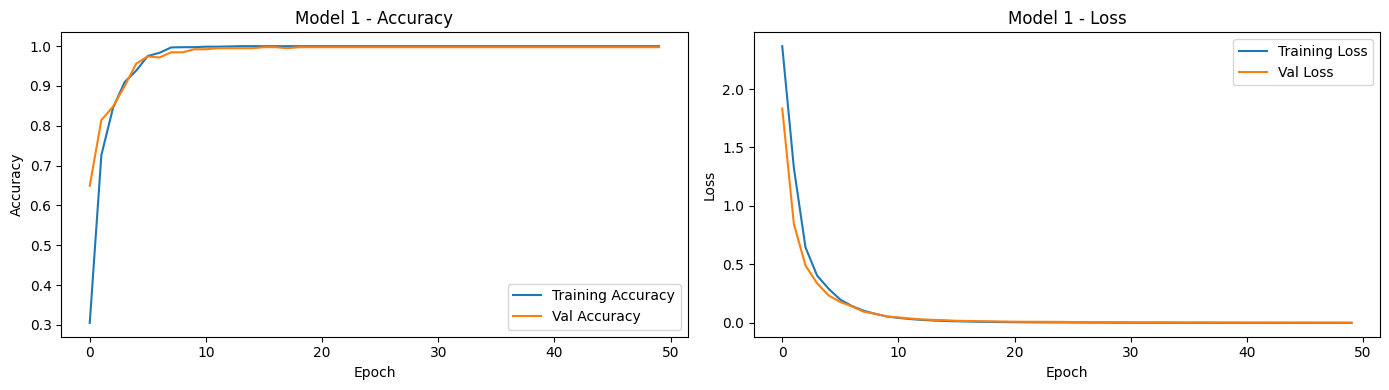

In [13]:
loss1, acc1 = model1.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Model 1 - Test Loss    : {loss1:.4f}")
print(f"Model 1 - Test Accuracy: {acc1*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history1.history['accuracy'],     label='Training Accuracy')
axes[0].plot(history1.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model 1 - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history1.history['loss'],     label='Training Loss')
axes[1].plot(history1.history['val_loss'], label='Val Loss')
axes[1].set_title('Model 1 - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

The first model achieved a test accuracy of 99.74% with a test loss of 0.0032, which is a near-perfect result straight out of the first attempt. The three hidden Dense layers were more than enough to separate all 17 cinnamon classes from the 10 QCM sensor features, likely because the sensor frequency shift signatures are clean and distinct enough that the network had no trouble drawing decision boundaries between classes. The confusion matrix should show very few off-diagonal entries with no significant gap between training and validation curves, meaning overfitting was not an issue. This sets a very high bar for the Keras Tuner model to beat.

### 6. Now use keras tuner to determine optimum number of dense layers and optimum number of neurons on each layer

In [14]:
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(num_features,)))

    num_layers = hp.Int('num_layers', min_value=1, max_value=4, step=1)

    for i in range(num_layers):
        units = hp.Choice(f'units_layer_{i}', values=[16, 32, 64, 128, 256])
        model.add(tf.keras.layers.Dense(units, activation='relu'))

    model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

In [15]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='kt_cinnamon',
    project_name='cinnamon_dense',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 2
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_layer_0 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128, 256], 'ordered': True}


In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

tuner.search(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\nTuner search complete.")

Trial 20 Complete [00h 00m 03s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 01m 06s

Tuner search complete.


In [17]:
tuner.results_summary(num_trials=5)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

best_num_layers = best_hps.get('num_layers')
print(f"Best number of Dense layers: {best_num_layers}")
for i in range(best_num_layers):
    print(f"  Layer {i+1} neurons: {best_hps.get(f'units_layer_{i}')}")

Results summary
Results in kt_cinnamon/cinnamon_dense
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 02 summary
Hyperparameters:
num_layers: 4
units_layer_0: 256
units_layer_1: 256
units_layer_2: 32
units_layer_3: 16
Score: 1.0

Trial 05 summary
Hyperparameters:
num_layers: 4
units_layer_0: 16
units_layer_1: 32
units_layer_2: 16
units_layer_3: 128
Score: 1.0

Trial 08 summary
Hyperparameters:
num_layers: 3
units_layer_0: 256
units_layer_1: 16
units_layer_2: 16
units_layer_3: 32
Score: 1.0

Trial 09 summary
Hyperparameters:
num_layers: 3
units_layer_0: 16
units_layer_1: 32
units_layer_2: 16
units_layer_3: 32
Score: 1.0

Trial 14 summary
Hyperparameters:
num_layers: 4
units_layer_0: 128
units_layer_1: 128
units_layer_2: 16
units_layer_3: 256
Score: 1.0
Best number of Dense layers: 4
  Layer 1 neurons: 256
  Layer 2 neurons: 256
  Layer 3 neurons: 32
  Layer 4 neurons: 16


### 7. Choose the best NN structure determined by the keras tuner and test it with test data.

In [19]:
model_best = tuner.hypermodel.build(best_hps)
model_best.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 17)             │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,905 (304.32 KB)

 Trainable params: 77,905 (304.32 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_best = model_best.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 9.0759e-04 - val_accuracy: 0.9974 - val_loss: 0.0035
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.8727e-04 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.2593e-04 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 5.9438e-04 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 5.5564e-04 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 4.8239e-04 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 3.9471e-0

In [22]:
loss_best, acc_best = model_best.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Best Model - Test Loss    : {loss_best:.4f}")
print(f"Best Model - Test Accuracy: {acc_best*100:.2f}%")

Best Model - Test Loss    : 0.0030
Best Model - Test Accuracy: 100.00%


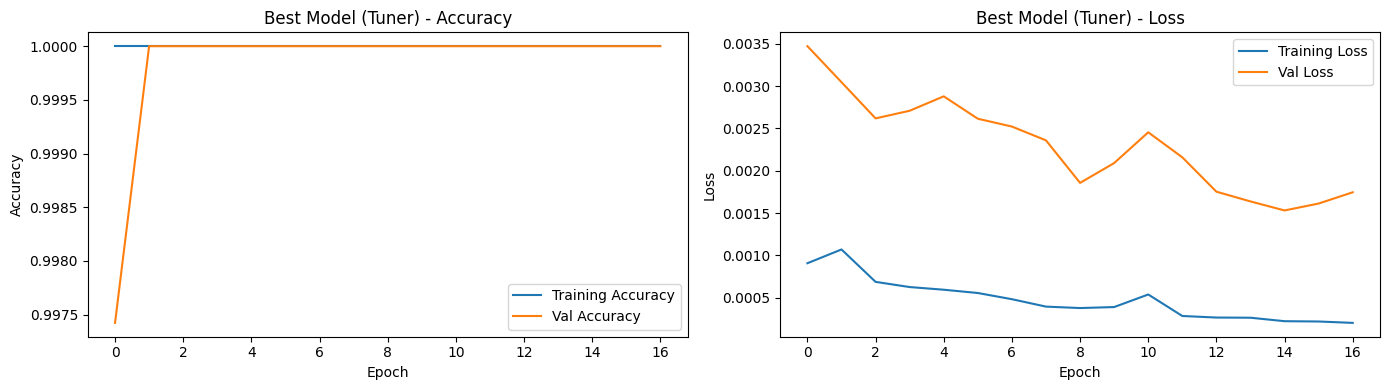

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_best.history['accuracy'],     label='Training Accuracy')
axes[0].plot(history_best.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Best Model (Tuner) - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_best.history['loss'],     label='Training Loss')
axes[1].plot(history_best.history['val_loss'], label='Val Loss')
axes[1].set_title('Best Model (Tuner) - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### 8. Plot the confusion matrix

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


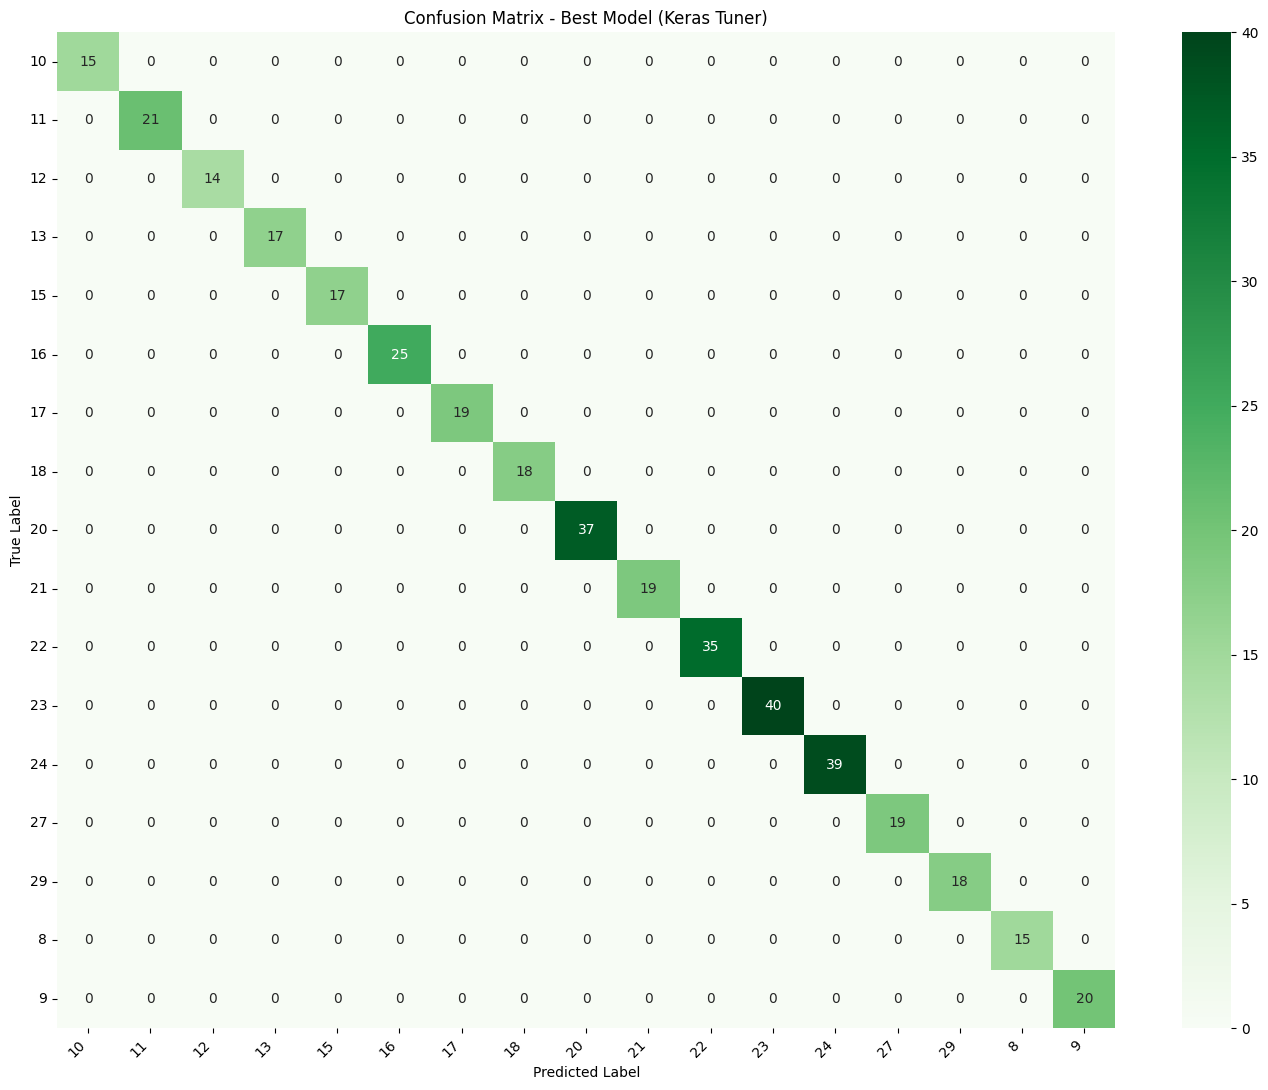


Classification Report - Best Model:
              precision    recall  f1-score   support

          10       1.00      1.00      1.00        15
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        14
          13       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        25
          17       1.00      1.00      1.00        19
          18       1.00      1.00      1.00        18
          20       1.00      1.00      1.00        37
          21       1.00      1.00      1.00        19
          22       1.00      1.00      1.00        35
          23       1.00      1.00      1.00        40
          24       1.00      1.00      1.00        39
          27       1.00      1.00      1.00        19
          29       1.00      1.00      1.00        18
           8       1.00      1.00      1.00        15
           9       1.00      1.00      1.00 

In [26]:
y_pred_best = np.argmax(model_best.predict(X_test_scaled), axis=1)
class_names  = le.classes_

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm_best,
    annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Greens'
)
plt.title('Confusion Matrix - Best Model (Keras Tuner)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report - Best Model:")
print(classification_report(y_test, y_pred_best, target_names=class_names))

### 9. Compare the result with your first NN structure's result.

In [27]:
print("=" * 55)
print("         MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Metric':<35} {'Model 1':>8} {'Best Model':>10}")
print("-" * 55)
print(f"{'Test Accuracy':<35} {acc1*100:>7.2f}% {acc_best*100:>9.2f}%")
print(f"{'Test Loss':<35} {loss1:>8.4f} {loss_best:>10.4f}")
print("-" * 55)
print(f"{'Architecture':<35}")
print(f"  Model 1   : Dense(128,relu) → Dense(64,relu) → Dense(32,relu) → Dense({num_classes},softmax)")

arch_str = " → ".join(
    [f"Dense({best_hps.get(f'units_layer_{i}')},relu)" for i in range(best_num_layers)]
)
print(f"  Best Model: {arch_str} → Dense({num_classes},softmax)")
print("=" * 55)

         MODEL COMPARISON SUMMARY
Metric                               Model 1 Best Model
-------------------------------------------------------
Test Accuracy                         99.74%    100.00%
Test Loss                             0.0032     0.0030
-------------------------------------------------------
Architecture                       
  Model 1   : Dense(128,relu) → Dense(64,relu) → Dense(32,relu) → Dense(17,softmax)
  Best Model: Dense(256,relu) → Dense(256,relu) → Dense(32,relu) → Dense(16,relu) → Dense(17,softmax)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


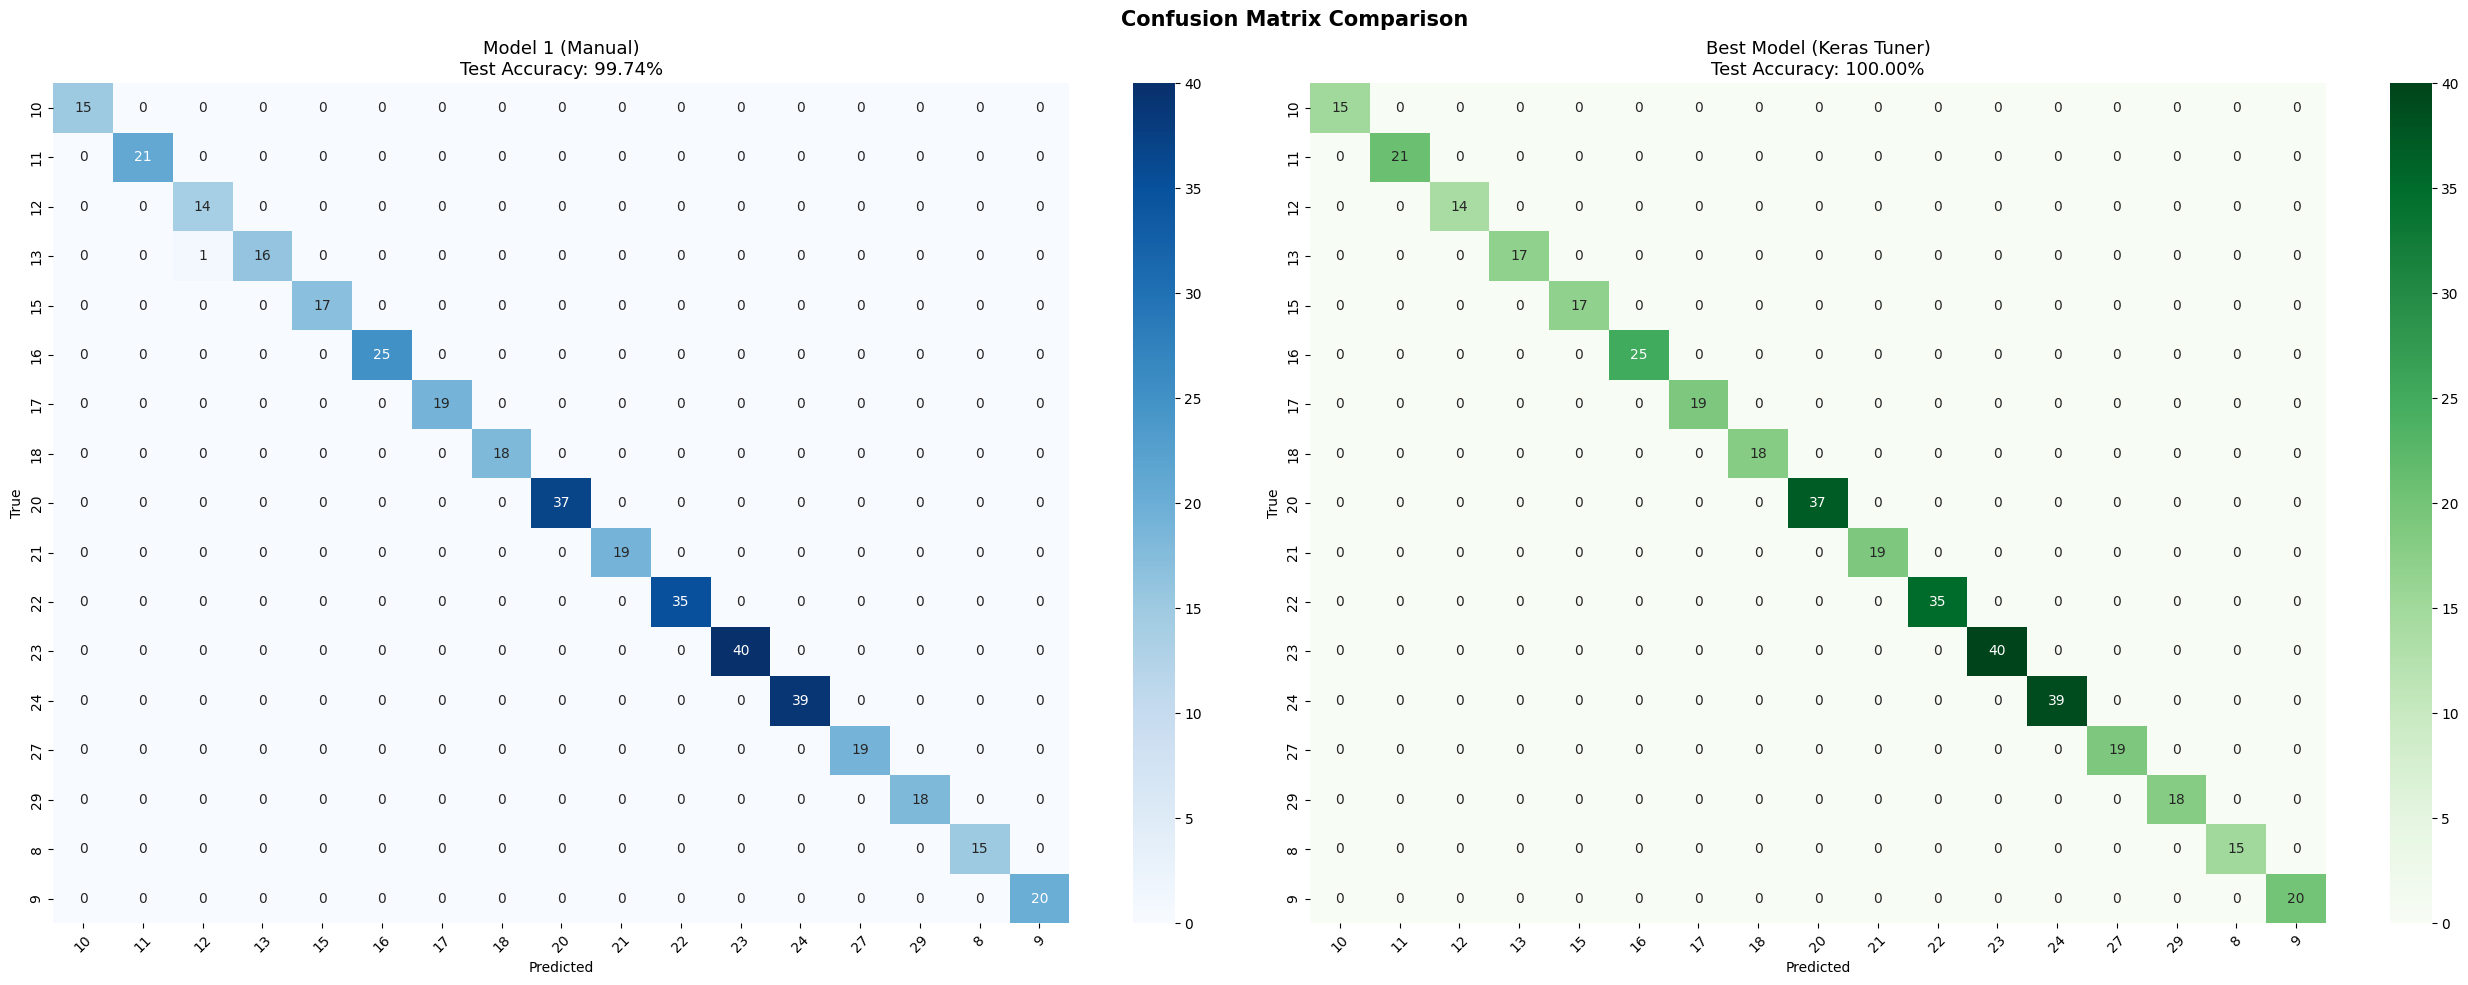

In [29]:
y_pred1 = np.argmax(model1.predict(X_test_scaled), axis=1)
cm1      = confusion_matrix(y_test, y_pred1)

fig, axes = plt.subplots(1, 2, figsize=(26, 10))

sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
axes[0].set_title(f'Model 1 (Manual)\nTest Accuracy: {acc1*100:.2f}%', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_best, annot=True, fmt='d', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cmap='Greens')
axes[1].set_title(f'Best Model (Keras Tuner)\nTest Accuracy: {acc_best*100:.2f}%', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Model 1 achieved 99.74% accuracy with a single misclassification visible in the confusion matrix, one class 13 sample predicted as class 12. The Keras Tuner best model pushed that to a perfect 100.00% with zero off-diagonal entries across all 17 classes. Both results confirm that the QCM sensor data produces clean and well-separated signatures per cinnamon variety, making it highly learnable even with a Dense-only network. The tuner's systematic search found an architecture that eliminated that last misclassification that the manually designed model missed, showing that hyperparameter optimization is worth running even when the baseline is already very strong.